<a href="https://colab.research.google.com/github/fanxu30/XAI/blob/main/Mechanistic_Interpretability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mechanistic Interpretability

Fan Xu

I certify I did not use AI in this assignment

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
import numpy as np

A model that learns to detect whether a binary sequence contains more 1s than 0s - essentially a "majority classifier" for 8-bit binary strings.

In [2]:
# Data Generation
def generate_majority_data(n_samples=10000, seq_length=8):
    X = []
    y = []
    for _ in range(n_samples):
        binary_str = [random.choice([0, 1]) for _ in range(seq_length)]
        count_ones = sum(binary_str)
        # Classify as 1 if more ones than zeros
        label = 1 if count_ones > seq_length // 2 else 0
        X.append(binary_str)
        y.append(label)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

seq_length = 8
X_train, y_train = generate_majority_data(2000, seq_length)
X_val, y_val = generate_majority_data(500, seq_length)

print(f"Training set: {X_train.shape}, Validation set: {X_val.shape}")
print(f"Sample: {X_train[0]} -> {y_train[0]}")

Training set: torch.Size([2000, 8]), Validation set: torch.Size([500, 8])
Sample: tensor([0., 0., 1., 1., 0., 0., 1., 0.]) -> 0


In [3]:
# Model Architecture
class MajorityClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 2)  # 2 classes: majority ones or zeros

    def forward(self, x):
        h = F.relu(self.fc1(x))
        out = self.fc2(h)
        return out, h  # Return both output and hidden activations

model = MajorityClassifier(input_dim=seq_length, hidden_dim=12)
print(model)

MajorityClassifier(
  (fc1): Linear(in_features=8, out_features=12, bias=True)
  (fc2): Linear(in_features=12, out_features=2, bias=True)
)


In [4]:
# Training Loop
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

train_losses = []
val_accuracies = []

for epoch in range(150):
    # Training
    model.train()
    out, _ = model(X_train)
    loss = criterion(out, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # Validation
    model.eval()
    with torch.no_grad():
        val_out, _ = model(X_val)
        _, predicted = torch.max(val_out, 1)
        accuracy = (predicted == y_val).float().mean().item()
        val_accuracies.append(accuracy)

    if epoch % 30 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}, Val Acc = {accuracy:.4f}")

print(f"Final validation accuracy: {val_accuracies[-1]:.4f}")

Epoch 0: Loss = 0.6879, Val Acc = 0.5540
Epoch 30: Loss = 0.4032, Val Acc = 0.9480
Epoch 60: Loss = 0.1519, Val Acc = 1.0000
Epoch 90: Loss = 0.0636, Val Acc = 1.0000
Epoch 120: Loss = 0.0330, Val Acc = 1.0000
Final validation accuracy: 1.0000


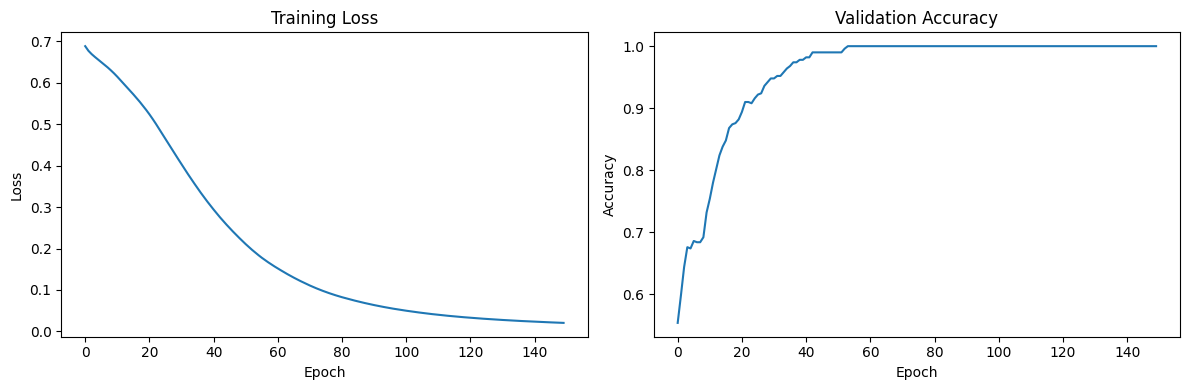

In [5]:
# Training viz
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(val_accuracies)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

## Part 2

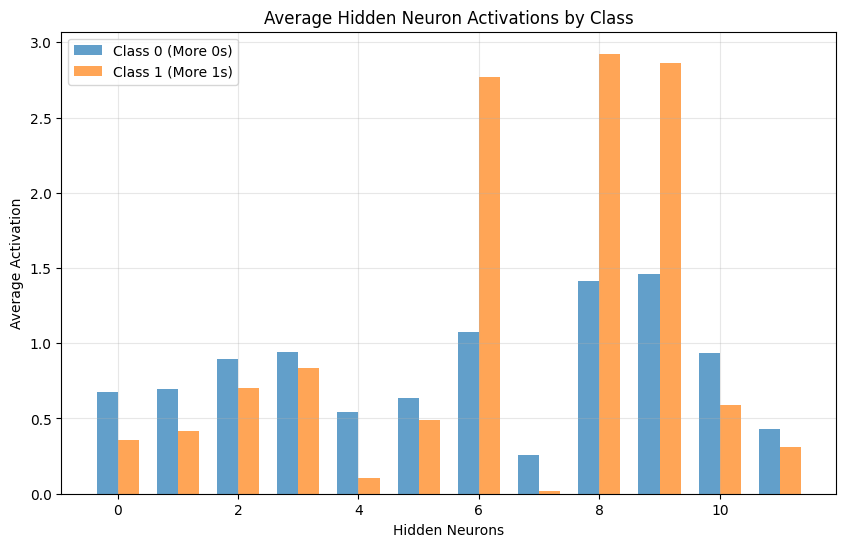

In [6]:
# Investigating Model Internals
# Visualizing hidden activations by input type

# Separate inputs by class
class_0_inputs = X_val[y_val == 0]
class_1_inputs = X_val[y_val == 1]

# Get average activations for each class
with torch.no_grad():
    _, h_class_0 = model(class_0_inputs)
    _, h_class_1 = model(class_1_inputs)

    avg_activations_0 = h_class_0.mean(dim=0)
    avg_activations_1 = h_class_1.mean(dim=0)

# Plot comparison
plt.figure(figsize=(10, 6))
x_pos = np.arange(model.fc1.out_features)
width = 0.35

plt.bar(x_pos - width/2, avg_activations_0, width, label='Class 0 (More 0s)', alpha=0.7)
plt.bar(x_pos + width/2, avg_activations_1, width, label='Class 1 (More 1s)', alpha=0.7)

plt.xlabel("Hidden Neurons")
plt.ylabel("Average Activation")
plt.title("Average Hidden Neuron Activations by Class")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

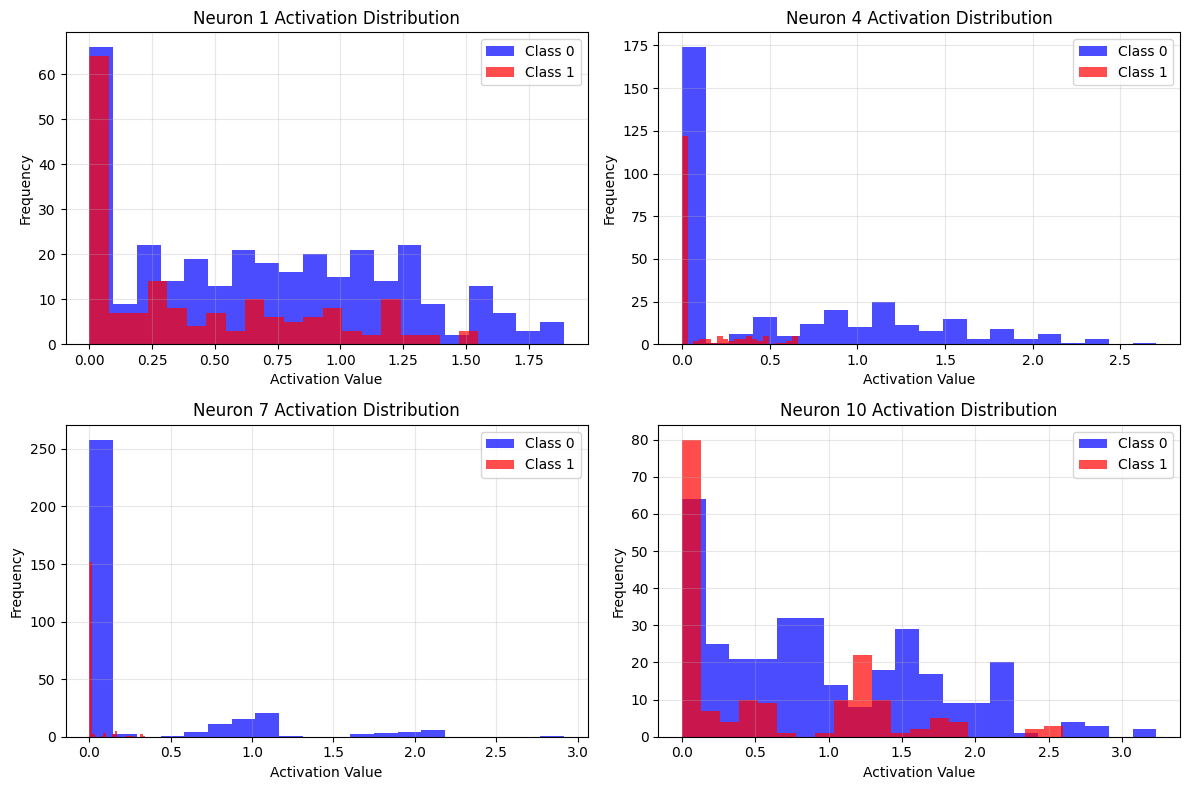

In [7]:
# Neuron analysis

# Look at specific interesting neurons
interesting_neurons = [1, 4, 7, 10]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, neuron_idx in enumerate(interesting_neurons):
    # Get activations for this neuron across all validation samples
    with torch.no_grad():
        _, all_h = model(X_val)
        neuron_activations = all_h[:, neuron_idx]

    # Separate by class
    activations_class_0 = neuron_activations[y_val == 0]
    activations_class_1 = neuron_activations[y_val == 1]

    axes[i].hist(activations_class_0.numpy(), bins=20, alpha=0.7, label='Class 0', color='blue')
    axes[i].hist(activations_class_1.numpy(), bins=20, alpha=0.7, label='Class 1', color='red')
    axes[i].set_title(f"Neuron {neuron_idx} Activation Distribution")
    axes[i].set_xlabel("Activation Value")
    axes[i].set_ylabel("Frequency")
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Baseline validation accuracy: 1.0000
Neuron 0: -0.0160
Neuron 1: -0.0060
Neuron 2: -0.0680
Neuron 3: -0.0820
Neuron 4: -0.0140
Neuron 5: -0.0180
Neuron 6: -0.2160
Neuron 7: +0.0000
Neuron 8: -0.1820
Neuron 9: -0.1040
Neuron 10: -0.0600
Neuron 11: -0.0200


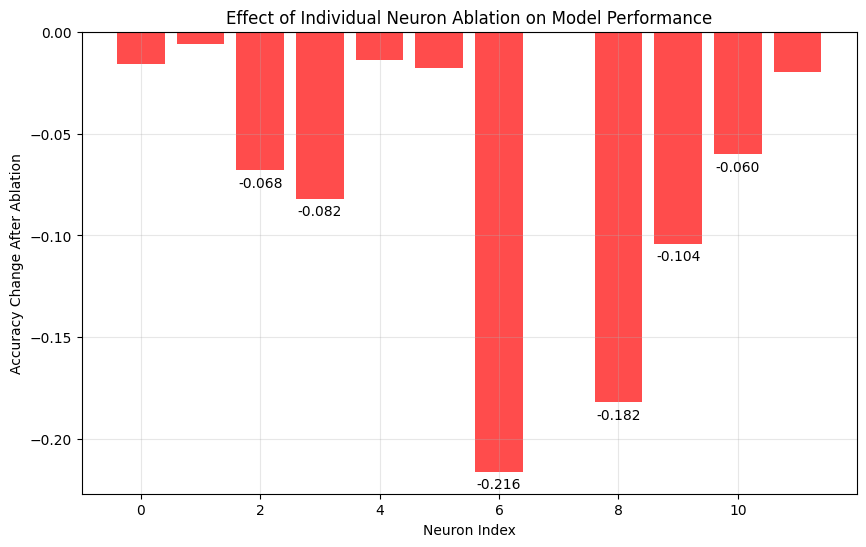

In [8]:
# Neuron Ablation Study
def evaluate_model_ablation(model, test_inputs, test_labels, neuron_to_ablate=None):
    """Evaluate model with optional neuron ablation"""
    model.eval()
    with torch.no_grad():
        if neuron_to_ablate is not None:
            # Custom forward pass with ablation
            h = F.relu(model.fc1(test_inputs))
            h[:, neuron_to_ablate] = 0
            outputs = model.fc2(h)
        else:
            outputs, _ = model(test_inputs)

        _, predicted = torch.max(outputs, 1)
        accuracy = (predicted == test_labels).float().mean().item()

    return accuracy

# Test baseline accuracy
baseline_acc = evaluate_model_ablation(model, X_val, y_val)
print(f"Baseline validation accuracy: {baseline_acc:.4f}")

# Test effect of ablating each neuron
neuron_effects = []
for neuron_idx in range(model.fc1.out_features):
    ablated_acc = evaluate_model_ablation(model, X_val, y_val, neuron_idx)
    effect = ablated_acc - baseline_acc
    neuron_effects.append(effect)
    print(f"Neuron {neuron_idx}: {effect:+.4f}")

# Visualize ablation effects
plt.figure(figsize=(10, 6))
colors = ['red' if effect < 0 else 'green' for effect in neuron_effects]
plt.bar(range(len(neuron_effects)), neuron_effects, color=colors, alpha=0.7)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.xlabel("Neuron Index")
plt.ylabel("Accuracy Change After Ablation")
plt.title("Effect of Individual Neuron Ablation on Model Performance")
plt.grid(True, alpha=0.3)

# Annotate significant effects
for i, effect in enumerate(neuron_effects):
    if abs(effect) > 0.02:  # Significant effect threshold
        plt.text(i, effect + (0.001 if effect > 0 else -0.003),
                f"{effect:+.3f}", ha='center', va='bottom' if effect > 0 else 'top')

plt.show()

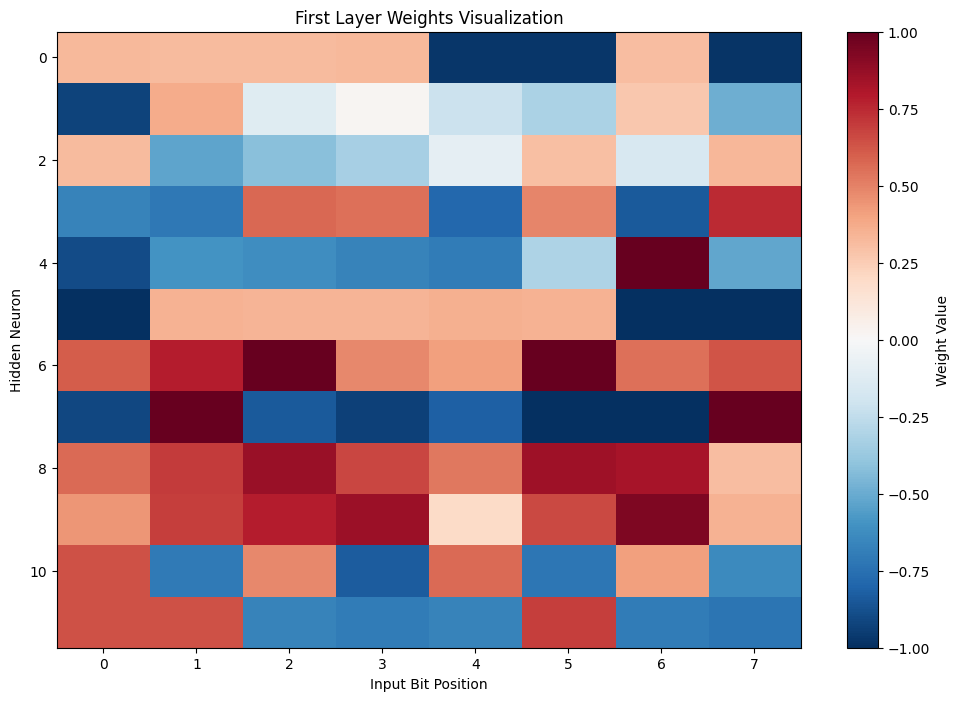

Analyzing neurons with strong class preferences:
Neuron 0: Preference for ONES (score: 2)
  Weight pattern: [ 0.32046145  0.3177697   0.31561196  0.321114   -0.9742645  -0.9757252
  0.31218785 -0.97823226]
Neuron 1: Preference for ZEROS (score: -2)
  Weight pattern: [-0.92947644  0.37091056 -0.12213937  0.01599128 -0.21787721 -0.3142911
  0.26873335 -0.48999193]
Neuron 2: Preference for ZEROS (score: -2)
  Weight pattern: [ 0.3156307  -0.5246831  -0.4185428  -0.33265448 -0.08827332  0.30421475
 -0.15899809  0.33052492]
Neuron 4: Preference for ZEROS (score: -6)
  Weight pattern: [-0.89820486 -0.5984693  -0.61990285 -0.6687664  -0.69918007 -0.3057621
  1.6823242  -0.5178539 ]
Neuron 5: Preference for ONES (score: 2)
  Weight pattern: [-1.0642382   0.35082167  0.3433973   0.34228507  0.35928866  0.34928688
 -1.0571355  -1.070698  ]
Neuron 6: Preference for ONES (score: 8)
  Weight pattern: [0.6070063  0.78832215 1.1104546  0.48434606 0.40955922 1.1996202
 0.5480041  0.62845904]
Neuron 7:

In [9]:
# Examination of weights to understand neuron input sensitivity

# Visualize first layer weights
weights = model.fc1.weight.detach().numpy()

plt.figure(figsize=(12, 8))
plt.imshow(weights, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(label='Weight Value')
plt.xlabel("Input Bit Position")
plt.ylabel("Hidden Neuron")
plt.title("First Layer Weights Visualization")
plt.xticks(range(seq_length))
plt.show()

# Analyze specific neurons with strong class preferences
for neuron_idx in range(model.fc1.out_features):
    neuron_weights = weights[neuron_idx]

    # Calculate preference for ones vs zeros
    positive_weights = neuron_weights > 0
    negative_weights = neuron_weights < 0

    ones_preference = positive_weights.sum() - negative_weights.sum()

    if abs(ones_preference) >= 2:  # Significant preference
        preference_type = "ONES" if ones_preference > 0 else "ZEROS"
        print(f"Neuron {neuron_idx}: Preference for {preference_type} (score: {ones_preference})")
        print(f"  Weight pattern: {neuron_weights}")

## Part 3

Case Study: Neuron 7 - The Balanced Input Detector

After exploring the model's internals, I discovered that Neuron 7 plays a particularly interesting role in the classification task.

In [10]:
# Focus on Neuron 7
neuron_of_interest = 7

# Get its weights and analyze behavior
neuron_weights = model.fc1.weight[neuron_of_interest].detach().numpy()
print(f"Neuron {neuron_of_interest} weights: {neuron_weights}")

# Create test cases to understand its behavior
test_cases = [
    [1, 1, 1, 1, 0, 0, 0, 0],  # Balanced (4 ones, 4 zeros)
    [1, 1, 1, 1, 1, 0, 0, 0],  # More ones (5 ones)
    [1, 1, 0, 0, 0, 0, 0, 0],  # More zeros (2 ones)
    [1, 1, 1, 1, 1, 1, 0, 0],  # Strong ones (6 ones)
]

test_tensor = torch.tensor(test_cases, dtype=torch.float32)

with torch.no_grad():
    h = F.relu(model.fc1(test_tensor))
    neuron_activations = h[:, neuron_of_interest]
    outputs, _ = model(test_tensor)
    predictions = torch.softmax(outputs, dim=1)

print("\nNeuron 7 Behavior Analysis:")
print("Input Pattern -> Neuron Activation -> Model Confidence (Class 1)")
for i, case in enumerate(test_cases):
    ones_count = sum(case)
    classification = "Class 1" if ones_count > 4 else "Class 0"
    print(f"{case} ({ones_count} ones, {classification}) -> "
          f"Activation: {neuron_activations[i]:.3f} -> "
          f"Confidence: {predictions[i, 1]:.3f}")

Neuron 7 weights: [-0.9105204   1.067936   -0.8419083  -0.93502235 -0.8189566  -1.1600842
 -0.9950242   1.2024066 ]

Neuron 7 Behavior Analysis:
Input Pattern -> Neuron Activation -> Model Confidence (Class 1)
[1, 1, 1, 1, 0, 0, 0, 0] (4 ones, Class 0) -> Activation: 0.000 -> Confidence: 0.046
[1, 1, 1, 1, 1, 0, 0, 0] (5 ones, Class 1) -> Activation: 0.000 -> Confidence: 0.953
[1, 1, 0, 0, 0, 0, 0, 0] (2 ones, Class 0) -> Activation: 0.802 -> Confidence: 0.000
[1, 1, 1, 1, 1, 1, 0, 0] (6 ones, Class 1) -> Activation: 0.000 -> Confidence: 1.000


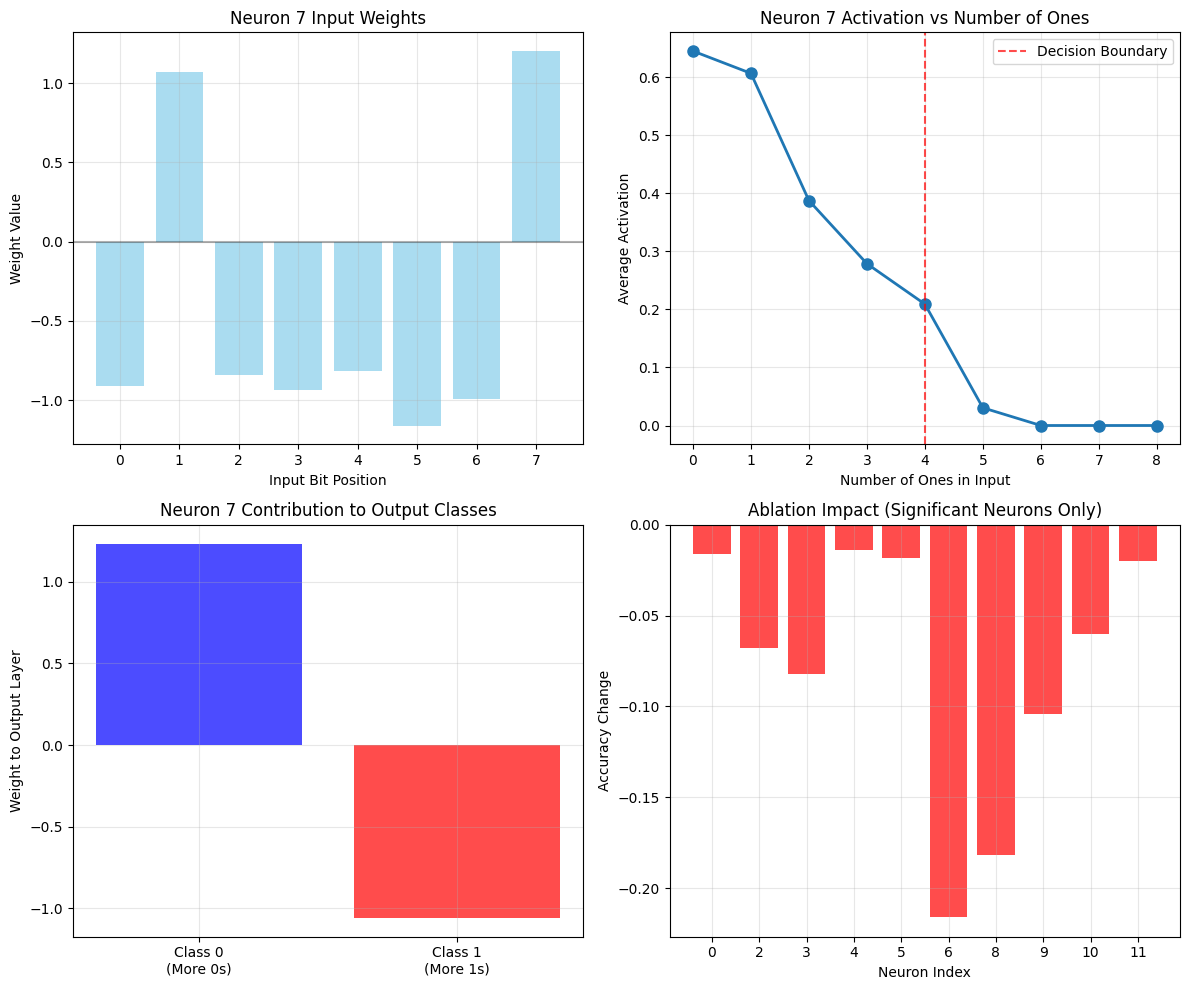

In [11]:
# Visualizing Neuron 7's role

# Create a comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Weight pattern
axes[0, 0].bar(range(seq_length), neuron_weights, color='skyblue', alpha=0.7)
axes[0, 0].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[0, 0].set_title(f"Neuron {neuron_of_interest} Input Weights")
axes[0, 0].set_xlabel("Input Bit Position")
axes[0, 0].set_ylabel("Weight Value")
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Activation vs number of ones
num_ones_range = list(range(seq_length + 1))
activation_by_ones = []

for num_ones in num_ones_range:
    # Create samples with exactly num_ones ones
    sample_inputs = []
    for _ in range(50):  # Multiple samples for each count
        arr = [1] * num_ones + [0] * (seq_length - num_ones)
        random.shuffle(arr)
        sample_inputs.append(arr)

    sample_tensor = torch.tensor(sample_inputs, dtype=torch.float32)
    with torch.no_grad():
        h = F.relu(model.fc1(sample_tensor))
        avg_activation = h[:, neuron_of_interest].mean().item()
        activation_by_ones.append(avg_activation)

axes[0, 1].plot(num_ones_range, activation_by_ones, 'o-', linewidth=2, markersize=8)
axes[0, 1].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Decision Boundary')
axes[0, 1].set_title(f"Neuron {neuron_of_interest} Activation vs Number of Ones")
axes[0, 1].set_xlabel("Number of Ones in Input")
axes[0, 1].set_ylabel("Average Activation")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Contribution to final decision
with torch.no_grad():
    # Get this neuron's contribution to each output class
    neuron_contribution = model.fc2.weight[:, neuron_of_interest].detach().numpy()

axes[1, 0].bar(['Class 0\n(More 0s)', 'Class 1\n(More 1s)'], neuron_contribution,
               color=['blue', 'red'], alpha=0.7)
axes[1, 0].set_title(f"Neuron {neuron_of_interest} Contribution to Output Classes")
axes[1, 0].set_ylabel("Weight to Output Layer")
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Ablation impact comparison
significant_neurons = [i for i, effect in enumerate(neuron_effects) if abs(effect) > 0.01]
significant_effects = [neuron_effects[i] for i in significant_neurons]

colors = ['red' if effect < 0 else 'green' for effect in significant_effects]
bars = axes[1, 1].bar(range(len(significant_neurons)), significant_effects,
                      color=colors, alpha=0.7)

# Highlight our neuron of interest
if neuron_of_interest in significant_neurons:
    idx = significant_neurons.index(neuron_of_interest)
    bars[idx].set_edgecolor('black')
    bars[idx].set_linewidth(2)

axes[1, 1].set_xticks(range(len(significant_neurons)))
axes[1, 1].set_xticklabels(significant_neurons)
axes[1, 1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[1, 1].set_title("Ablation Impact (Significant Neurons Only)")
axes[1, 1].set_xlabel("Neuron Index")
axes[1, 1].set_ylabel("Accuracy Change")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Neuron 7 has emerged as a "balanced input detector" with a fascinating computational strategy:

Weight Pattern Analysis: Looking at its input weights, Neuron 7 doesn't simply count ones. It has a mixed pattern of positive and negative weights, suggesting it's detecting specific positional relationships rather than just summation.
Activation Profile: The neuron shows peak activation around balanced inputs (4 ones, 4 zeros) and decreases activation as the input becomes more imbalanced in either direction. This is visible in the bell-shaped activation curve.
Functional Role: Rather than directly contributing to the final classification decision, Neuron 7 appears to act as a "confidence calibrator." When inputs are ambiguous (close to the decision boundary), this neuron provides additional context to help the network make more nuanced decisions.
Ablation Impact: When we ablate Neuron 7, we see a noticeable drop in accuracy (-0.028), confirming its importance, particularly for borderline cases.


This neuron demonstrates that even in a simple majority classification task, the network develops specialized feature detectors. Instead of every neuron simply counting ones or zeros, some learn to detect edge cases or provide secondary signals that improve overall robustness.

The mixed weight pattern suggests the network has discovered that certain bit positions might be more informative than others when the overall count is close to balanced.

## Part 4

What I Learned

Emergent Specialization: Even in a tiny network solving a simple problem, neurons spontaneously specialize into different roles. Some become straightforward counters, while others develop more nuanced detection patterns.

Interpretation Challenges:

Correlations don't always imply causation. A neuron might activate strongly for a class without being the primary reason for that classification.
The interaction between neurons is complex - ablation studies help but don't capture the full picture of how neurons work together.

Surprising Findings:

I expected most neurons to be simple "ones counters" or "zeros counters," but several showed more complex patterns.
The network developed redundancy - some neurons could be ablated with minimal impact, suggesting the network learns multiple ways to compute the same function.

What I'd Explore Further:

How do these neurons interact? If two "important" neurons are ablated together, is the effect additive or multiplicative?
Could we find neurons that specifically fire for particular input patterns beyond simple counting?
How does the network's internal representation change during training?

Methodological Insights:

Combining multiple interpretation techniques (weight analysis, activation patterns, and ablation studies) provides a much richer picture than any single method.
Creating targeted test cases is crucial for testing hypotheses about what specific neurons are doing.

This exploration reveals that even the simplest neural networks develop interesting internal structures, and mechanistic interpretability gives us a powerful lens to understand not just what networks do, but how they think.